In [64]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development.

In [66]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("/content/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development.
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [67]:
print(data.columns.tolist())

['text', 'label']


In [69]:
from sklearn.model_selection import train_test_split


# Split into train and validation sets
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)

print("Train size:", data_train.shape)
print("Validation size:", data_val.shape)

Train size: (800, 3)
Validation size: (200, 3)


## Data Preprocessing


In [70]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [71]:
import string
from nltk.corpus import stopwords
#nltk.download('stopwords')

print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [72]:
# Your code
import re

def clean_html(text):
    # 1. Remove inline JavaScript/CSS
    text = re.sub(r'<(script|style)[^>]*>.*?</(script|style)>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 2. Remove HTML comments (before regular tags since comments can contain '>')
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

    # 3. Remove remaining HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    return text.strip()

# Apply to your dataset
data['text'] = data['text'].apply(clean_html)

print(data['text'].head())

0    DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...
1                                             Will do.
2    Nora--Cheryl has emailed dozens of memos about...
3    Dear Sir=2FMadam=2C I know that this proposal ...
4                                                  fyi
Name: text, dtype: object


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters

- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [73]:
# Your code
def clean_text(text):
    # Remove special characters
    text = re.sub(r'\W', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove all single characters
    text = re.sub(r'\s+[a-zA-Z]\s', ' ', text)

    # Remove single characters from the start
    text = re.sub(r'^[a-zA-Z]\s+', ' ', text)

    # Substitute multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text, flags=re.I)

    # Remove prefixed 'b'
    text = re.sub(r'b\s+', '', text)

    # Convert to lowercase
    text = text.lower()

    return text

# Call function
data['text'] = data['text'].apply(clean_text)

print(data['text'].head())



0    dear sir strictly private business proposal am...
1                                             will do 
2    nora cheryl has emailed dozens of memos about ...
3    dear sir fmadam i know that this proposal migh...
4                                                  fyi
Name: text, dtype: object


## Now let's work on removing stopwords
Remove the stopwords.

In [74]:
# Your code
from nltk.corpus import stopwords

def remove_stopwords(text):
  stop_words = set(stopwords.words('english'))
  words = text.split()
  filtered_words = [word for word in words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

data['text'] = data['text'].apply(remove_stopwords)
print(data['text'].head())

0    dear sir strictly private business proposal mi...
1                                                     
2    nora cheryl emailed dozens memos haiti weekend...
3    dear sir fmadam know proposal might surprise e...
4                                                  fyi
Name: text, dtype: object


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [75]:
# Your code
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [76]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

data['text'] = data['text'].apply(lemmatize_text)
print(data['text'].head())

0    dear sir strictly private business proposal mi...
1                                                     
2    nora cheryl emailed dozen memo haiti weekend p...
3    dear sir fmadam know proposal might surprise e...
4                                                  fyi
Name: text, dtype: object


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

In [77]:
print(data.columns.tolist())
print(data['label'].value_counts())  # replace 'label' with your actual label column

['text', 'label', 'preprocessed_text']
label
0    558
1    442
Name: count, dtype: int64


Top 10 words in HAM (legitimate) emails:
  â: 244
  state: 136
  pm: 127
  would: 107
  ã: 103
  president: 99
  time: 95
  call: 94
  mr: 91
  obama: 84

Top 10 words in SPAM (fraudulent) emails:
  money: 981
  account: 895
  bank: 799
  fund: 781
  u: 760
  transaction: 549
  business: 514
  country: 508
  mr: 487
  nbsp: 475


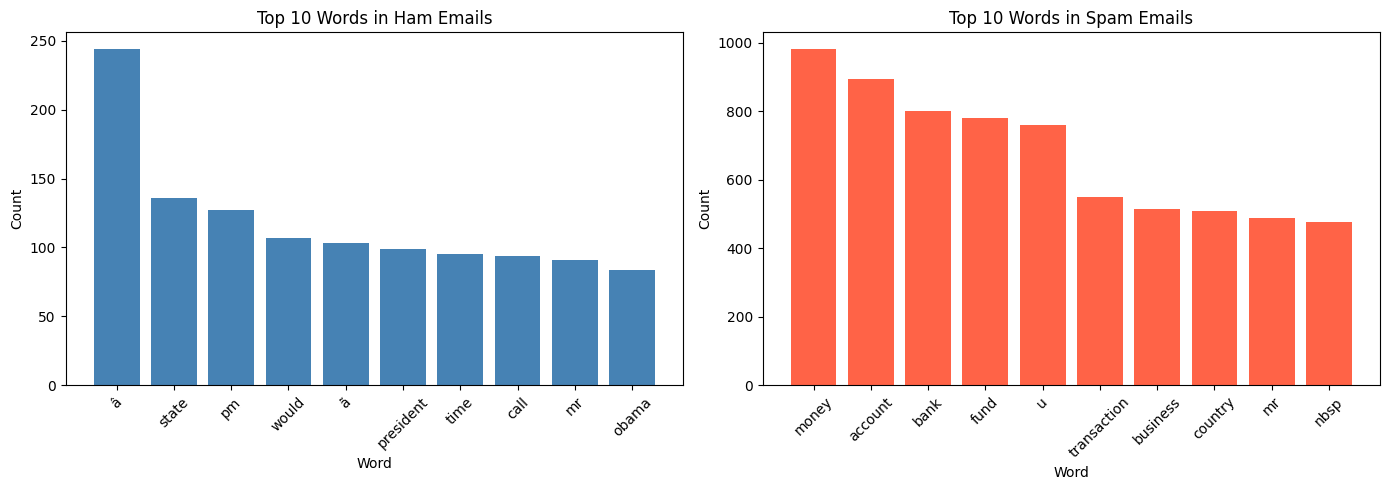

In [78]:
# Your code
from collections import Counter

# Separate ham and spam
ham_texts = data[data['label'] == 0]['text']
spam_texts = data[data['label'] == 1]['text']

# Combine all words for each category
ham_words = ' '.join(ham_texts).split()
spam_words = ' '.join(spam_texts).split()

# Count and get top 10
ham_top10 = Counter(ham_words).most_common(10)
spam_top10 = Counter(spam_words).most_common(10)

print("Top 10 words in HAM (legitimate) emails:")
for word, count in ham_top10:
    print(f"  {word}: {count}")

print("\nTop 10 words in SPAM (fraudulent) emails:")
for word, count in spam_top10:
    print(f"  {word}: {count}")

# Visualise
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ham bar chart
ham_words_list, ham_counts = zip(*ham_top10)
ax1.bar(ham_words_list, ham_counts, color='steelblue')
ax1.set_title('Top 10 Words in Ham Emails')
ax1.set_xlabel('Word')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Spam bar chart
spam_words_list, spam_counts = zip(*spam_top10)
ax2.bar(spam_words_list, spam_counts, color='tomato')
ax2.set_title('Top 10 Words in Spam Emails')
ax2.set_xlabel('Word')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Extra features

In [79]:
data['preprocessed_text'] = data['text']

In [80]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x))

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x))

data_train.head()

,text,label,preprocessed_text,money_mark,suspicious_words,text_len
29,"----------- REGARDS, MR NELSON SMITH.KINDLY RE...",1,"----------- REGARDS, MR NELSON SMITH.KINDLY RE...",0,0,106
535,I have not been able to reach oscar this am. W...,0,I have not been able to reach oscar this am. W...,0,0,101
695,; Huma Abedin B6I'm checking with Pat on the 5...,0,; Huma Abedin B6I'm checking with Pat on the 5...,0,0,141
557,I can have it announced here on Monday - can't...,0,I can have it announced here on Monday - can't...,0,0,52
836,BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...,1,BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...,0,1,1750


## How would work the Bag of Words with Count Vectorizer concept?

In [87]:
# Your code
from sklearn.feature_extraction.text import CountVectorizer

# Initialise the vectorizer
vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train = vectorizer.fit_transform(data_train['preprocessed_text'])
x_val = vectorizer.transform(data_val['preprocessed_text'])

y_train = data_train['label']
y_val = data_val['label']

print(X_train.shape)
print(list(vectorizer.vocabulary_.keys())[:10])

(800, 5000)
['regards', 'mr', 'nelson', 'smith', 'kindly', 'reply', 'me', 'on', 'my', 'private']


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [88]:
# Your
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    min_df = 2,
    max_df = 0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf = tfidf_vectorizer.transform(data_val['preprocessed_text'])

print(X_train_tfidf.shape)
print(X_val_tfidf.shape)

(800, 5000)
(200, 5000)


## And the Train a Classifier?

              precision    recall  f1-score   support

         Ham       0.99      0.91      0.95       125
        Spam       0.87      0.99      0.93        75

    accuracy                           0.94       200
   macro avg       0.93      0.95      0.94       200
weighted avg       0.95      0.94      0.94       200



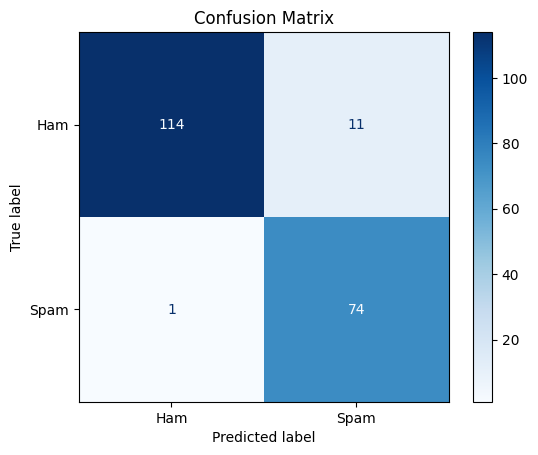

In [89]:
# Your code
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Train the classifier
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 2. Predict on validation set
y_pred = model.predict(X_val_tfidf)

# 3. Print classification report
print(classification_report(y_val, y_pred, target_names=['Ham', 'Spam']))

# 4. Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [94]:
# Your code
import kagglehub

#kagglehub.login()

In [92]:
path = kagglehub.competition_download('dsub-fraudulentemails')
print("Path to competition files:", path)

100%|██████████| 6.14M/6.14M [00:00<00:00, 47.2MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/dsub-fraudulentemails


In [100]:
import pandas as pd
import numpy as np
import re
import zipfile
import collections
import nltk
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import MinMaxScaler
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# ── 1. Load Data ──────────────────────────────────────────────────────────────
data = pd.read_csv("/content/kg_train.csv", encoding='latin-1')
data = data.head(1000)
data.fillna("", inplace=True)

# ── 2. Clean HTML ─────────────────────────────────────────────────────────────
def clean_html(text):
    text = re.sub(r'<(script|style)[^>]*>.*?</(script|style)>', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', '', text)
    return text.strip()

# ── 3. Clean Text ─────────────────────────────────────────────────────────────
def clean_text(text):
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'^[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub(r'^b\s+', '', text)
    text = text.lower()
    return text.strip()

# ── 4. Remove Stopwords ───────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

# ── 5. Lemmatize ──────────────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

# ── 6. Apply Preprocessing ────────────────────────────────────────────────────
data['preprocessed_text'] = (data['text']
    .apply(clean_html)
    .apply(clean_text)
    .apply(remove_stopwords)
    .apply(lemmatize_text))

# ── 7. Extra Flags ────────────────────────────────────────────────────────────
money_symbol_list  = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words   = "|".join(["free","cheap","sex","money","account","bank",
                                "fund","transfer","transaction","win","deposit","password"])

data['money_mark']       = data['preprocessed_text'].str.contains(money_symbol_list) * 1
data['suspicious_words'] = data['preprocessed_text'].str.contains(suspicious_words) * 1
data['text_len']         = data['preprocessed_text'].apply(len)

# ── 8. Train/Val Split ────────────────────────────────────────────────────────
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)

y_train = data_train['label']
y_val   = data_val['label']

# ── 9. Vectorizers ────────────────────────────────────────────────────────────
bow   = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)

X_train_bow   = bow.fit_transform(data_train['preprocessed_text'])
X_val_bow     = bow.transform(data_val['preprocessed_text'])

X_train_tfidf = tfidf.fit_transform(data_train['preprocessed_text'])
X_val_tfidf   = tfidf.transform(data_val['preprocessed_text'])

# Scale extra flags (MinMaxScaler so they work with MultinomialNB — no negative values)
scaler = MinMaxScaler()
extra_train = scaler.fit_transform(data_train[['money_mark','suspicious_words','text_len']])
extra_val   = scaler.transform(data_val[['money_mark','suspicious_words','text_len']])

# ── 10. Test All 4 Combinations ───────────────────────────────────────────────
experiments = {
    "BoW only":           (X_train_bow,                                    X_val_bow),
    "TF-IDF only":        (X_train_tfidf,                                  X_val_tfidf),
    "BoW + extra flags":  (sp.hstack([X_train_bow,   extra_train]),        sp.hstack([X_val_bow,   extra_val])),
    "TF-IDF + extra flags":(sp.hstack([X_train_tfidf, extra_train]),       sp.hstack([X_val_tfidf, extra_val])),
}

print("=" * 60)
results = {}
for name, (X_tr, X_vl) in experiments.items():
    model = MultinomialNB()   # default parameters — not changed!
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_vl)
    f1 = f1_score(y_val, y_pred, average='weighted')
    results[name] = f1
    print(f"\n📊 {name}")
    print(classification_report(y_val, y_pred, target_names=['Ham','Spam']))

# ── 11. Summary ───────────────────────────────────────────────────────────────
print("=" * 60)
print("SUMMARY — Weighted F1 Scores:")
for name, f1 in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {f1:.4f}  →  {name}")

best = max(results, key=results.get)
print(f"\n✅ Best combination: {best}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



📊 BoW only
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       125
        Spam       0.96      0.97      0.97        75

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98      0.97      0.98       200


📊 TF-IDF only
              precision    recall  f1-score   support

         Ham       0.99      0.96      0.98       125
        Spam       0.94      0.99      0.96        75

    accuracy                           0.97       200
   macro avg       0.96      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200


📊 BoW + extra flags
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       125
        Spam       0.96      0.97      0.97        75

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98   